# Entrenamiento XGBoost para Clasificación de la Técnica de Sentadilla

**Pipeline de procesamiento:**
1. Exploración del conjunto de datos: detección de personas mediante YOLOv8-pose
2. Extracción de keypoints multi-persona por fotograma con seguimiento greedy
3. Cálculo de ángulos biomecánicos por persona (rodilla, cadera, espalda, simetría)
4. Agregación de estadísticos (media, desviación estándar, mínimo y máximo) por video
5. Corrección del desbalance de clases mediante `scale_pos_weight`
6. Entrenamiento de XGBoost con validación cruzada estratificada (Accuracy, F1, ROC-AUC)
7. Optimización de hiperparámetros con GridSearchCV
8. Comparación de XGBoost vs. clasificador por reglas biomecánicas sobre el conjunto de prueba

> **Enfoque:** este notebook entrena un clasificador de aprendizaje automático sobre datos reales y lo compara
> contra el `SquatFormClassifier` basado en reglas biomecánicas derivadas de literatura deportiva.
> Ambos enfoques utilizan los mismos ángulos articulares extraídos mediante YOLOv8-pose.

## Resumen

Este notebook implementa un pipeline completo de clasificación de la técnica de sentadilla (*squat*) mediante visión por computador y aprendizaje automático supervisado. El sistema emplea YOLOv8-pose para extraer 17 keypoints corporales por fotograma, a partir de los cuales se calculan ángulos articulares (rodilla, cadera, espalda) y métricas de simetría bilateral. Dichas métricas se agregan estadísticamente por video (media, desviación estándar, mínimo y máximo) y se utilizan como vector de características para entrenar un clasificador XGBoost. Se implementan buenas prácticas de aprendizaje automático: corrección del desbalance de clases mediante `scale_pos_weight`, validación cruzada estratificada de 5 pliegues y optimización de hiperparámetros por búsqueda exhaustiva en cuadrícula (GridSearchCV). El modelo resultante se compara de forma justa contra un clasificador basado en reglas biomecánicas, evaluando ambos enfoques sobre el mismo conjunto de prueba reservado.

---

## Introducción

La evaluación de la técnica en ejercicios de fuerza, como la sentadilla, requiere tradicionalmente la supervisión de un profesional con formación específica. La proliferación de cámaras de alta resolución y modelos de estimación de pose en tiempo real abre la posibilidad de automatizar esta evaluación mediante métodos computacionales, haciéndola accesible a un público más amplio.

El presente trabajo propone dos enfoques complementarios para clasificar la ejecución de una sentadilla como correcta o deficiente:

1. **Reglas biomecánicas**: umbrales fijos derivados de la literatura deportiva, implementados en `src/squat_classifier.py`. Este enfoque es interpretable y no requiere datos de entrenamiento.

2. **Clasificador XGBoost**: modelo de aprendizaje automático entrenado sobre vectores de características extraídos automáticamente de videos etiquetados. Este enfoque tiene el potencial de capturar patrones más complejos y generalizables a medida que el conjunto de datos crece.

Ambos enfoques comparten el mismo módulo de extracción de características basado en YOLOv8-pose, lo que garantiza que la comparación sea equitativa y que las diferencias de rendimiento se atribuyan exclusivamente a la estrategia de clasificación.

El conjunto de datos está compuesto por 19 videos propios, distribuidos en dos categorías: `squat_correcto` (7 videos) y `squatmal_ejecutado` (12 videos). Dado que YOLOv8-pose detecta múltiples personas por fotograma, se aplica un algoritmo de seguimiento greedy que genera 46 muestras (tracks) a nivel de persona, con un desbalance de clases de 17 correctas frente a 29 deficientes.

---
## 1. Importación de Módulos y Configuración

In [ ]:
import os, sys, math, warnings
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

import joblib

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Imports listos")


✅ Imports listos


In [ ]:
# Rutas
DATA_DIR = Path("data_videos")
CLASSES = {
    "squat_correcto": 0,       # buena forma
    "squatmal_ejecutado": 1,   # mala forma
}
OUTPUT_MODEL = Path("models/xgboost_squat.pkl")

# Parámetros de procesamiento 
FRAME_SKIP = 3        # procesar 1 de cada N frames
CONF_THRESH = 0.5     # confianza mínima de detección
TRACK_DIST_THRESH = 200  # px máx para considerar misma persona entre frames
YOLO_MODEL = "yolov8n-pose.pt"

# COCO keypoint indices
(NOSE, L_EYE, R_EYE, L_EAR, R_EAR,
 L_SHOULDER, R_SHOULDER, L_ELBOW, R_ELBOW,
 L_WRIST, R_WRIST, L_HIP, R_HIP,
 L_KNEE, R_KNEE, L_ANKLE, R_ANKLE) = range(17)

print(f"Videos en: {DATA_DIR.resolve()}")
print(f"Clases: {CLASSES}")


📁 Videos en: C:\Users\julia\OneDrive\Documents\ESPECIALIZACIÓN IA\Vision_Computacional\proyecto-vision\data_videos
📦 Clases: {'squat_correcto': 0, 'squatmal_ejecutado': 1}


---
## 2. Funciones de Cálculo de Ángulos Biomecánicos

Cada función opera sobre los keypoints de una persona representados como diccionario `{id: {x, y}}`. Se implementan las siguientes operaciones geométricas:

- `angle_between`: calcula el ángulo en grados entre dos vectores mediante el producto punto normalizado.
- `angle_3pt`: calcula el ángulo formado por tres puntos P1–P2–P3 con vértice en P2, aplicando `angle_between` sobre los vectores resultantes.
- `get_squat_angles`: extrae los ángulos relevantes para la evaluación de la sentadilla (rodilla, cadera, ángulo de espalda respecto a la vertical, desplazamiento rodilla-tobillo y simetría bilateral).

In [ ]:
# Geometría 

def angle_between(v1: np.ndarray, v2: np.ndarray) -> float:
    """Ángulo (en grados) entre dos vectores."""
    dot = float(np.dot(v1, v2))
    norm = float(np.linalg.norm(v1) * np.linalg.norm(v2))
    if norm < 1e-8:
        return 90.0
    cos_angle = max(-1.0, min(1.0, dot / norm))
    return float(np.degrees(np.arccos(cos_angle)))


def angle_3pt(p1, p2, p3) -> float:
    """Ángulo P1–P2–P3 con vértice en P2 (en grados)."""
    v1 = np.array([p1[0] - p2[0], p1[1] - p2[1]])
    v2 = np.array([p3[0] - p2[0], p3[1] - p2[1]])
    return angle_between(v1, v2)


# Ángulos específicos de sentadilla

def get_squat_angles(kps: dict) -> dict:
    """
    kps: {id: {x, y}}  (COCO keypoints de UNA persona)
    Retorna dict con ángulos calculados.
    """
    angles = {}

    def pt(idx):
        p = kps.get(idx)
        return (p["x"], p["y"]) if p is not None else None

    # obtener los puntos de hip, knee y ankle para mabos lados
    for side, hip_id, knee_id, ankle_id in [
        ("left", L_HIP, L_KNEE, L_ANKLE),
        ("right", R_HIP, R_KNEE, R_ANKLE),
    ]:
        hip, knee, ankle = pt(hip_id), pt(knee_id), pt(ankle_id)
        if hip and knee and ankle:
            angles[f"{side}_knee_angle"] = angle_3pt(hip, knee, ankle)

    # Cadera (hombro → cadera → rodilla)
    for side, sh_id, hip_id, knee_id in [
        ("left", L_SHOULDER, L_HIP, L_KNEE),
        ("right", R_SHOULDER, R_HIP, R_KNEE),
    ]:
        sh, hip, knee = pt(sh_id), pt(hip_id), pt(knee_id)
        if sh and hip and knee:
            angles[f"{side}_hip_angle"] = angle_3pt(sh, hip, knee)

    # Espalda (torso vs vertical)
    ls, rs, lh, rh = pt(L_SHOULDER), pt(R_SHOULDER), pt(L_HIP), pt(R_HIP)
    if all(p is not None for p in [ls, rs, lh, rh]):
        mid_sh = np.mean([ls, rs], axis=0)
        mid_hip = np.mean([lh, rh], axis=0)
        torso = mid_sh - mid_hip
        vertical = np.array([0.0, -1.0])
        angles["back_angle"] = angle_between(torso, vertical)

    # Knee-over-toe
    for side, knee_id, ankle_id in [
        ("left", L_KNEE, L_ANKLE),
        ("right", R_KNEE, R_ANKLE),
    ]:
        knee, ankle = pt(knee_id), pt(ankle_id)
        if knee and ankle:
            angles[f"{side}_knee_toe_x"] = float(knee[0] - ankle[0])

    # Simetría
    if "left_knee_angle" in angles and "right_knee_angle" in angles:
        angles["knee_symmetry"] = abs(angles["left_knee_angle"] - angles["right_knee_angle"])
    if "left_hip_angle" in angles and "right_hip_angle" in angles:
        angles["hip_symmetry"] = abs(angles["left_hip_angle"] - angles["right_hip_angle"])

    return angles


# Features agregadas por video

ANGLE_KEYS = [
    "left_knee_angle", "right_knee_angle",
    "left_hip_angle", "right_hip_angle",
    "back_angle", "left_knee_toe_x", "right_knee_toe_x",
    "knee_symmetry", "hip_symmetry",
]


def aggregate_features(frame_angles: list[dict]) -> dict:
    """
    Toma una lista de dicts (uno por frame) y calcula
    estadísticos agregados (mean, std, min, max) para cada métrica.
    """
    if not frame_angles:
        return {}

    all_keys = set()
    for fa in frame_angles:
        all_keys.update(fa.keys())

    features = {}
    for key in sorted(all_keys):
        vals = [fa[key] for fa in frame_angles if key in fa]
        if not vals:
            continue
        arr = np.array(vals, dtype=np.float64)
        features[f"{key}_mean"] = float(np.mean(arr))
        features[f"{key}_std"] = float(np.std(arr))
        features[f"{key}_min"] = float(np.min(arr))
        features[f"{key}_max"] = float(np.max(arr))

    return features


print("Funciones de ángulos y features listas")

✅ Funciones de ángulos y features listas


---
## 3. Seguimiento Multi-Persona

YOLOv8-pose detecta simultáneamente a todas las personas presentes en cada fotograma. Para mantener la identidad de cada persona a lo largo del video, se implementa un algoritmo de **seguimiento por proximidad** del centroide del bounding box entre fotogramas consecutivos.

### Algoritmo de seguimiento (greedy matching):
1. Por cada fotograma, extraer los bounding boxes de todas las personas detectadas.
2. Calcular el centroide del bounding box para cada detección.
3. Comparar los centroides actuales con los del fotograma anterior.
4. Asignación greedy: cada detección nueva se empareja con el track más cercano disponible.
5. Si la distancia supera `TRACK_DIST_THRESH` píxeles, se inicializa un nuevo track independiente.

In [ ]:
def bbox_center(bbox):
    """Centro (x, y) de un bbox [x1, y1, x2, y2]."""
    return ((bbox[0] + bbox[2]) / 2, (bbox[1] + bbox[3]) / 2)


def greedy_match(current_centers, prev_centers, max_dist):
    """
    Empareja detecciones actuales con tracks previos.

    Returns
    -------
    assignments : list[(track_idx, det_idx)]
        Emparejamientos track → detección.
    unmatched_dets : list[int]
        Índices de detecciones sin track previo (personas nuevas).
    """
    assignments = []
    used_prev = set()
    used_curr = set()

    # Para cada detección actual, encontrar el track previo más cercano
    for det_idx, c_center in enumerate(current_centers):
        best_dist = max_dist
        best_prev = None
        for prev_idx, p_center in enumerate(prev_centers):
            if prev_idx in used_prev:
                continue
            dist = np.linalg.norm(np.array(c_center) - np.array(p_center))
            if dist < best_dist:
                best_dist = dist
                best_prev = prev_idx

        if best_prev is not None:
            assignments.append((best_prev, det_idx))
            used_prev.add(best_prev)
            used_curr.add(det_idx)

    unmatched = [i for i in range(len(current_centers)) if i not in used_curr]
    return assignments, unmatched


def process_video_multi(video_path: str, model: YOLO,
                        frame_skip: int = 3,
                        conf_thresh: float = 0.5,
                        track_dist: float = 200.0):
    """
    Procesa un video y devuelve los tracks de cada persona.

    Parameters
    ----------
    video_path : str
        Ruta al video.
    model : YOLO
        Modelo YOLO cargado.
    frame_skip : int
        Procesar 1 de cada N frames.
    conf_thresh : float
        Confianza mínima de detección.
    track_dist : float
        Distancia máxima (px) para considerar misma persona.

    Returns
    -------
    list[dict]
        Cada elemento::
            {track_id, keypoints_per_frame: [{frame, dict_kps}],
             angles_per_frame: [{frame, angle_dict}],
             n_frames: int}
    """
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    tracks: dict[int, dict] = {}       # track_id -> track data
    prev_centers: dict[int, tuple] = {}  # track_id -> center (x, y)
    next_track_id = 0
    frame_num = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_num % frame_skip != 0:
            frame_num += 1
            continue

        results = model(frame, verbose=False)
        if (results[0].keypoints is None
                or len(results[0].keypoints.xy) == 0
                or results[0].boxes is None):
            frame_num += 1
            continue

        n_people = len(results[0].keypoints.xy)

        # Armar detecciones actuales
        current_dets = []
        current_centers = []
        for p_idx in range(n_people):
            bbox = results[0].boxes.xyxy[p_idx].tolist()
            det_conf = float(results[0].boxes.conf[p_idx].item())
            if det_conf < conf_thresh:
                continue

            kp_list = []
            kps = results[0].keypoints
            for i in range(len(kps.xy[p_idx])):
                x, y = kps.xy[p_idx][i].tolist()
                c = float(kps.conf[p_idx][i].item())
                kp_list.append({"id": i, "x": x, "y": y, "confidence": c})

            current_dets.append({"keypoints": kp_list, "bbox": bbox, "conf": det_conf})
            current_centers.append(bbox_center(bbox))

        if not current_dets:
            frame_num += 1
            continue

        # Matching greedy con tracks previos
        prev_list = list(prev_centers.items())  # [(track_id, center), ...]
        prev_ids = [p[0] for p in prev_list]
        prev_cent = [p[1] for p in prev_list]

        if not prev_cent:
            # Primer frame: todos son nuevos tracks
            for det_idx, det in enumerate(current_dets):
                tid = next_track_id
                next_track_id += 1
                kps_dict = {kp["id"]: {"x": kp["x"], "y": kp["y"]}
                            for kp in det["keypoints"]}
                angles = get_squat_angles(kps_dict)
                tracks[tid] = {
                    "track_id": tid,
                    "keypoints_per_frame": [{"frame": frame_num, "keypoints": kps_dict}],
                    "angles_per_frame": [{"frame": frame_num, "angles": angles}] if angles else [],
                    "n_frames": 1,
                }
                prev_centers[tid] = current_centers[det_idx]
        else:
            assignments, unmatched = greedy_match(current_centers, prev_cent, track_dist)

            # Actualizar tracks existentes
            new_centers = {}
            for track_idx, det_idx in assignments:
                tid = prev_ids[track_idx]
                det = current_dets[det_idx]
                kps_dict = {kp["id"]: {"x": kp["x"], "y": kp["y"]}
                            for kp in det["keypoints"]}
                angles = get_squat_angles(kps_dict)
                tracks[tid]["keypoints_per_frame"].append({"frame": frame_num, "keypoints": kps_dict})
                if angles:
                    tracks[tid]["angles_per_frame"].append({"frame": frame_num, "angles": angles})
                tracks[tid]["n_frames"] += 1
                new_centers[tid] = current_centers[det_idx]

            # Nuevos tracks para detecciones no emparejadas
            for det_idx in unmatched:
                tid = next_track_id
                next_track_id += 1
                det = current_dets[det_idx]
                kps_dict = {kp["id"]: {"x": kp["x"], "y": kp["y"]}
                            for kp in det["keypoints"]}
                angles = get_squat_angles(kps_dict)
                tracks[tid] = {
                    "track_id": tid,
                    "keypoints_per_frame": [{"frame": frame_num, "keypoints": kps_dict}],
                    "angles_per_frame": [{"frame": frame_num, "angles": angles}] if angles else [],
                    "n_frames": 1,
                }
                new_centers[tid] = current_centers[det_idx]

            prev_centers = new_centers

        frame_num += 1

    cap.release()
    return list(tracks.values())


print("Función de tracking multi-persona lista")


✅ Función de tracking multi-persona lista


---
## 4. Análisis Exploratorio del Conjunto de Datos

Se enumeran todos los videos disponibles por clase, se verifica la distribución de resoluciones y se realiza una prueba de detección con YOLOv8-pose para confirmar el funcionamiento del pipeline antes del procesamiento completo.

In [ ]:
# Listar videos

videos = []
for class_name, label in CLASSES.items():
    class_dir = DATA_DIR / class_name
    if not class_dir.exists():
        print(f"No existe: {class_dir}")
        continue
    for f in sorted(class_dir.iterdir()):
        if f.suffix.lower() in (".mov", ".mp4", ".avi", ".mkv"):
            videos.append({"path": str(f), "class": class_name, "label": label})

df_videos = pd.DataFrame(videos)
print(f"Total videos: {len(df_videos)}")
print(df_videos.groupby("class").size().to_string())
print()

# Info de resolución

resolutions = []
for v in df_videos.sample(min(5, len(df_videos))).itertuples():
    cap = cv2.VideoCapture(v.path)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    dur = total / fps if fps > 0 else 0
    cap.release()
    resolutions.append({"video": Path(v.path).name, "width": w, "height": h,
                        "fps": fps, "frames": total, "duration_s": dur})

df_res = pd.DataFrame(resolutions)
print("Muestra de resoluciones:")
print(df_res.to_string(index=False))

Total videos: 19
class
squat_correcto         7
squatmal_ejecutado    12

Muestra de resoluciones:
       video  width  height       fps  frames  duration_s
IMG_0983.MOV   1080    1920 30.005377     279    9.298333
IMG_1050.MOV   1080    1920 29.984464     193    6.436667
IMG_1018.MOV   1080    1920 30.000000     229    7.633333
IMG_0984.MOV   1080    1920 30.000000     243    8.100000
IMG_1014.MOV   1080    1920 30.000000     212    7.066667


In [ ]:
# Probar detección en un video 

model = YOLO(YOLO_MODEL)
print(f"Modelo cargado: {YOLO_MODEL}")

# Procesar el primer video para ver cuántas personas detecta
test_video = df_videos.iloc[0]
test_class = getattr(test_video, "class")  # class is a keyword, must use getattr
print(f"\nVideo de prueba: {Path(test_video.path).name} ({test_class})")

tracks = process_video_multi(
    test_video.path, model,
    frame_skip=30,  # rápido: sample 1 de cada 30 frames
    conf_thresh=CONF_THRESH,
    track_dist=TRACK_DIST_THRESH,
)

n_people = len(tracks)
print(f"Personas detectadas: {n_people}")
for t in tracks:
    print(f"   Track #{t['track_id']}: {t['n_frames']} frames, "
          f"{len(t['angles_per_frame'])} frames con ángulos")


✅ Modelo cargado: yolov8n-pose.pt

📹 Video de prueba: IMG_0983.MOV (squat_correcto)
👥 Personas detectadas: 3
   Track #0: 9 frames, 9 frames con ángulos
   Track #1: 10 frames, 10 frames con ángulos
   Track #2: 1 frames, 1 frames con ángulos


---
## 5. Extracción de Características de Todos los Videos

Se aplica el pipeline de procesamiento sobre la totalidad del conjunto de datos:

1. Por cada video, se extraen los tracks correspondientes a cada persona detectada.
2. Por cada track, se calculan los ángulos biomecánicos fotograma a fotograma.
3. Los ángulos se agregan estadísticamente (media, desviación estándar, mínimo y máximo) por track, produciendo un vector de 36 características por muestra.
4. Cada muestra se etiqueta según la carpeta de origen: `squat_correcto` = 0, `squatmal_ejecutado` = 1.

Este procesamiento puede requerir varios minutos dependiendo del hardware disponible.

In [ ]:
# Procesamiento completo 

all_samples = []
error_log = []

for _, v in df_videos.iterrows():   # iterrows evita el problema de 'class' como keyword en itertuples
    video_name = Path(v["path"]).name
    video_class = v["class"]
    print(f"Procesando: {video_name} ({video_class}) ... ", end="", flush=True)

    try:
        tracks = process_video_multi(
            v["path"], model,
            frame_skip=FRAME_SKIP,
            conf_thresh=CONF_THRESH,
            track_dist=TRACK_DIST_THRESH,
        )

        if not tracks:
            print("sin detecciones")
            error_log.append({"video": video_name, "error": "no detections"})
            continue

        for t in tracks:
            if not t["angles_per_frame"]:
                continue

            frames_angles = [entry["angles"] for entry in t["angles_per_frame"]]
            features = aggregate_features(frames_angles)

            all_samples.append({
                "video": video_name,
                "track_id": t["track_id"],
                "label": v["label"],
                "class": video_class,
                "n_frames": t["n_frames"],
                "n_angles_frames": len(t["angles_per_frame"]),
                **features,
            })

        print(f"{len(tracks)} persona(s)")

    except Exception as e:
        print(f" {e}")
        error_log.append({"video": video_name, "error": str(e)})

print(f"\nTotal samples (personas): {len(all_samples)}")
if error_log:
    print(f"Errores: {len(error_log)}")
    for e in error_log:
        print(f"   {e['video']}: {e['error']}")

📹 Procesando: IMG_0983.MOV (squat_correcto) ... ✅ 2 persona(s)
📹 Procesando: IMG_0984.MOV (squat_correcto) ... ✅ 2 persona(s)
📹 Procesando: IMG_0985.MOV (squat_correcto) ... ✅ 2 persona(s)
📹 Procesando: IMG_0986.MOV (squat_correcto) ... ✅ 3 persona(s)
📹 Procesando: IMG_1048.MOV (squat_correcto) ... ✅ 3 persona(s)
📹 Procesando: IMG_1050.MOV (squat_correcto) ... ✅ 3 persona(s)
📹 Procesando: IMG_1051.mov (squat_correcto) ... ✅ 2 persona(s)
📹 Procesando: IMG_1013.MOV (squatmal_ejecutado) ... ✅ 2 persona(s)
📹 Procesando: IMG_1014.MOV (squatmal_ejecutado) ... ✅ 2 persona(s)
📹 Procesando: IMG_1016.MOV (squatmal_ejecutado) ... ✅ 2 persona(s)
📹 Procesando: IMG_1017.MOV (squatmal_ejecutado) ... ✅ 2 persona(s)
📹 Procesando: IMG_1018.MOV (squatmal_ejecutado) ... ✅ 2 persona(s)
📹 Procesando: IMG_1023.MOV (squatmal_ejecutado) ... ✅ 3 persona(s)
📹 Procesando: IMG_1024.MOV (squatmal_ejecutado) ... ✅ 2 persona(s)
📹 Procesando: IMG_1025.MOV (squatmal_ejecutado) ... ✅ 2 persona(s)
📹 Procesando: IMG_1027.

In [ ]:
# Armar DataFrame

df = pd.DataFrame(all_samples)
print(f"Dataset shape: {df.shape}")
print(f"Columnas: {len(df.columns)}")
print(f"  - Metadata: video, track_id, label, class, n_frames, n_angles_frames")
feature_cols = [c for c in df.columns if c.endswith(("_mean", "_std", "_min", "_max"))]
print(f"  - Features: {len(feature_cols)}")
print()

# Distribución de clases
print("Distribución de etiquetas:")
print(df["class"].value_counts().to_string())
print()

# Ver cuántas personas únicas detectamos
print(f"Videos únicos: {df['video'].nunique()}")
print(f"Tracks únicos (personas): {len(df)}")

Dataset shape: (46, 42)
Columnas: 42
  - Metadata: video, track_id, label, class, n_frames, n_angles_frames
  - Features: 36

Distribución de etiquetas:
class
squatmal_ejecutado    29
squat_correcto        17

Videos únicos: 19
Tracks únicos (personas): 46


Estadísticas por clase (features clave):
                   left_knee_angle_min                                       \
                                 count  mean   std   min   25%   50%    75%   
class                                                                         
squat_correcto                    17.0  74.8  35.0  36.9  49.4  55.9   93.8   
squatmal_ejecutado                29.0  95.3  33.6  23.9  72.4  98.3  115.2   

                          back_angle_mean        ... knee_symmetry_mean        \
                      max           count  mean  ...                75%   max   
class                                            ...                            
squat_correcto      155.6            17.0  10.5  ...               10.1  17.6   
squatmal_ejecutado  174.2            29.0  17.7  ...               10.9  29.3   

                   left_knee_toe_x_max                                      \
                                 count  mean   std   min   25%   50%   75%   
c

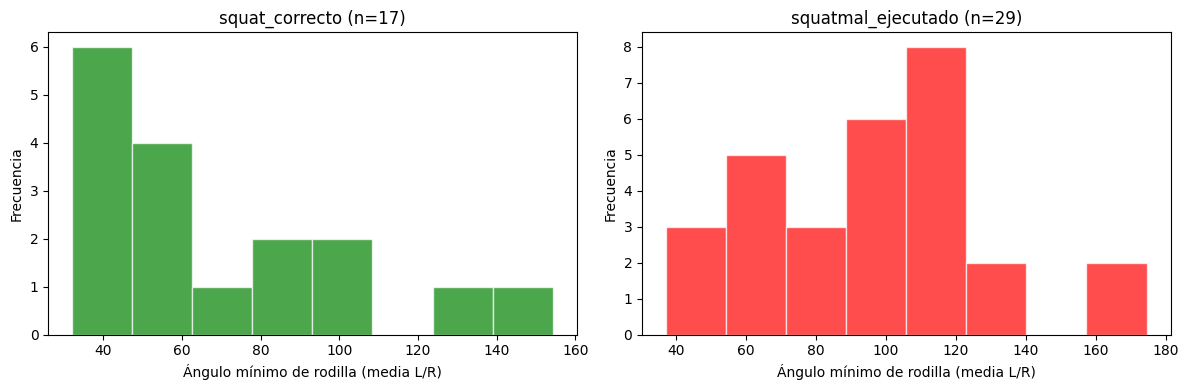

In [ ]:
# Análisis exploratorio rápido

# Mostrar estadísticas básicas de las features principales
key_feats = ["left_knee_angle_min", "back_angle_mean",
             "knee_symmetry_mean", "left_knee_toe_x_max"]
available = [k for k in key_feats if k in df.columns]
if available:
    print("Estadísticas por clase (features clave):")
    print(df.groupby("class")[available].describe().round(1))
    print()

# Distribución del ángulo mínimo de rodilla (profundidad)
if "left_knee_angle_min" in df.columns and "right_knee_angle_min" in df.columns:
    df["knee_min_avg"] = df[["left_knee_angle_min", "right_knee_angle_min"]].mean(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, cls, color in zip(axes, ["squat_correcto", "squatmal_ejecutado"], ["green", "red"]):
        subset = df[df["class"] == cls]["knee_min_avg"]
        ax.hist(subset, bins=8, alpha=0.7, color=color, edgecolor="white")
        ax.set_title(f"{cls} (n={len(subset)})")
        ax.set_xlabel("Ángulo mínimo de rodilla (media L/R)")
        ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


---
## 6. Construcción de la Matriz de Características

Se transforma el conjunto de datos en una matriz numérica apta para el entrenamiento, aplicando las siguientes decisiones de diseño:

- **Vector de características**: únicamente columnas con sufijos `_mean`, `_std`, `_min`, `_max` — estadísticos agregados de los ángulos por video (36 características en total).
- **Corrección del desbalance de clases**: `scale_pos_weight = n_correctas / n_deficientes`. Este parámetro instruye a XGBoost para que penalice proporcionalmente más los errores cometidos en la clase minoritaria.
- **Registro de índices del conjunto de prueba**: se almacena `idx_test` junto con la partición train/test para garantizar que la comparación con las reglas biomecánicas (Sección 9) se realice sobre exactamente las mismas muestras no vistas durante el entrenamiento.

In [ ]:
# Preparar X, y 

feature_cols = sorted([c for c in df.columns
                       if c.endswith(("_mean", "_std", "_min", "_max"))])
print(f"Features totales: {len(feature_cols)}")
print(f"Primeras 5: {feature_cols[:5]}")
print(f"Últimas 5:  {feature_cols[-5:]}")

X = df[feature_cols].values.astype(np.float64)
y = df["label"].values

# Manejar NaN / Inf 
n_nan = np.isnan(X).sum()
n_inf = np.isinf(X).sum()
if n_nan > 0 or n_inf > 0:
    print(f"NaN: {n_nan}, Inf: {n_inf} — reemplazando con 0")
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Clases: 0={sum(y==0)}, 1={sum(y==1)}")

# Desbalance de clases
n_neg = int(sum(y == 0))
n_pos = int(sum(y == 1))
scale_pos_weight = n_neg / n_pos
print(f"\n  Desbalance — scale_pos_weight: {scale_pos_weight:.2f}")
print(f"   ({n_neg} squat_correcto / {n_pos} squatmal_ejecutado)")

# ── Train / Test split — guardamos índices para comparación justa en Sec. 9 ──
indices = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices, test_size=0.25, random_state=42, stratify=y
)
print(f"\nSplit: train={len(X_train)}, test={len(X_test)}")
print(f"  Train: 0={sum(y_train==0)}, 1={sum(y_train==1)}")
print(f"  Test:  0={sum(y_test==0)}, 1={sum(y_test==1)}")

Features totales: 36
Primeras 5: ['back_angle_max', 'back_angle_mean', 'back_angle_min', 'back_angle_std', 'hip_symmetry_max']
Últimas 5:  ['right_knee_angle_std', 'right_knee_toe_x_max', 'right_knee_toe_x_mean', 'right_knee_toe_x_min', 'right_knee_toe_x_std']
X shape: (46, 36)
y shape: (46,)
Clases: 0=17, 1=29

⚖️  Desbalance — scale_pos_weight: 0.59
   (17 squat_correcto / 29 squatmal_ejecutado)

Split: train=34, test=12
  Train: 0=13, 1=21
  Test:  0=4, 1=8


---
## 7. Entrenamiento del Clasificador XGBoost

El entrenamiento se estructura en tres etapas:

1. **Modelo base**: configuración de parámetros razonables con `scale_pos_weight` para compensar el desbalance 17/29. Se reportan Accuracy, F1 y ROC-AUC sobre el conjunto de prueba.
2. **Validación cruzada estratificada** (5 pliegues): preserva las proporciones de clase en cada pliegue y reporta media ± desviación estándar de las tres métricas, lo que resulta más confiable que una única partición cuando el dataset es de tamaño reducido.
3. **GridSearchCV**: búsqueda exhaustiva de hiperparámetros (profundidad máxima, tasa de aprendizaje, número de estimadores, fracción de muestras por árbol) optimizando el AUC en 3 pliegues estratificados.

🎯 Accuracy: 66.67%
📐 F1 Score: 0.7500
📈 ROC-AUC:  0.7500

📋 Classification Report:
              precision    recall  f1-score   support

       Buena       0.50      0.50      0.50         4
        Mala       0.75      0.75      0.75         8

    accuracy                           0.67        12
   macro avg       0.62      0.62      0.62        12
weighted avg       0.67      0.67      0.67        12



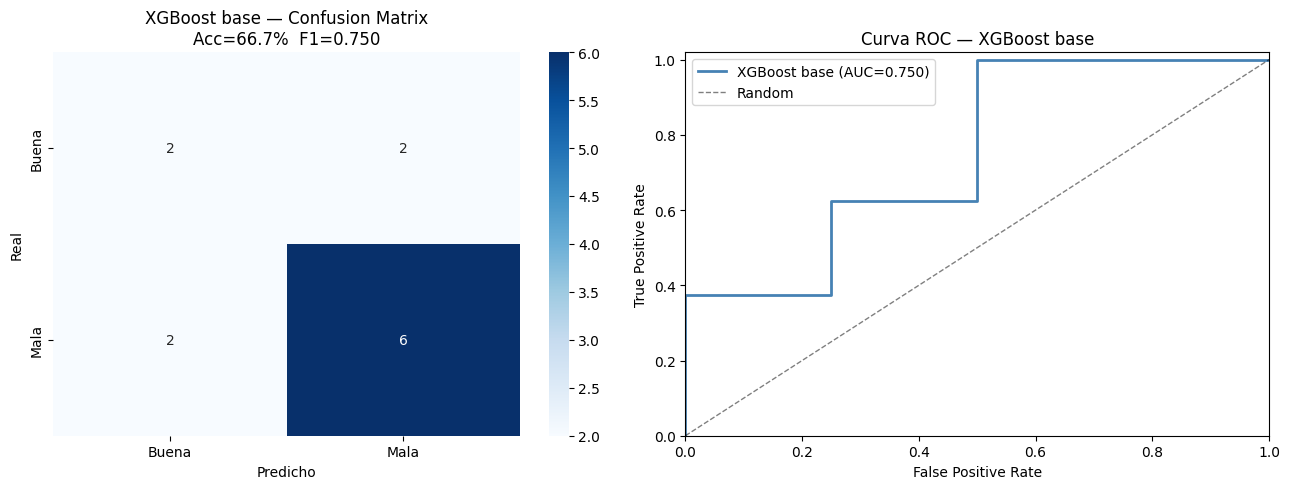

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

# Parámetros base

params = {
    "n_estimators": 200,
    "max_depth": 4,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,   # compensa 7 buenos vs 12 malos
    "random_state": 42,
    "eval_metric": "logloss",
}

xgb_clf = xgb.XGBClassifier(**params)
xgb_clf.fit(X_train, y_train)

# Predicciones 

y_pred_xgb  = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# Métricas

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb, zero_division=0)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"Accuracy: {acc_xgb:.2%}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"ROC-AUC:  {auc_xgb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=["Buena", "Mala"]))

# Confusion matrix + ROC curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Buena", "Mala"], yticklabels=["Buena", "Mala"], ax=axes[0])
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")
axes[0].set_title(f"XGBoost base — Confusion Matrix\nAcc={acc_xgb:.1%}  F1={f1_xgb:.3f}")

fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"XGBoost base (AUC={auc_xgb:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC — XGBoost base")
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

In [ ]:
# Validación cruzada estratificada 
# 5-fold estratificado: cada fold mantiene la proporción original de clases

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(xgb_clf, X, y, cv=cv, scoring="accuracy")
cv_f1  = cross_val_score(xgb_clf, X, y, cv=cv, scoring="f1")
cv_auc = cross_val_score(xgb_clf, X, y, cv=cv, scoring="roc_auc")

print("Cross-validation (5 folds, XGBoost base):")
print(f"  Accuracy  — Media: {cv_acc.mean():.2%} ± {cv_acc.std():.2%}  |  por fold: {cv_acc.round(3)}")
print(f"  F1 Score  — Media: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  |  por fold: {cv_f1.round(3)}")
print(f"  ROC-AUC   — Media: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}  |  por fold: {cv_auc.round(3)}")

Cross-validation (5 folds, XGBoost base):
  Accuracy  — Media: 69.56% ± 14.70%  |  por fold: [        0.7       0.444       0.778       0.667       0.889]
  F1 Score  — Media: 0.7681 ± 0.1248  |  por fold: [      0.769       0.545       0.833       0.769       0.923]
  ROC-AUC   — Media: 0.6894 ± 0.1944  |  por fold: [      0.708        0.35       0.667       0.778       0.944]


In [ ]:
# GridSearchCV para búsqueda de hiperparámetros
# Optimizamos AUC (más robusto que accuracy con clases desbalanceadas)
# Usamos 3-fold porque el dataset es chico y 5-fold deja muy pocas muestras por fold

from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth":     [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators":  [100, 200],
    "subsample":     [0.8, 1.0],
}

base_clf = xgb.XGBClassifier(
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
)

grid_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    base_clf, param_grid,
    cv=grid_cv, scoring="roc_auc",
    n_jobs=-1, verbose=0,
)
grid_search.fit(X, y)

print("✅ GridSearchCV completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")
print(f"   Mejor ROC-AUC (CV 3-fold): {grid_search.best_score_:.4f}")

# Reentrenar el mejor estimador sobre el split train/test original para comparar fairamente
best_clf = grid_search.best_estimator_
best_clf.fit(X_train, y_train)
y_pred_best  = best_clf.predict(X_test)
y_proba_best = best_clf.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
f1_best  = f1_score(y_test, y_pred_best, zero_division=0)
auc_best = roc_auc_score(y_test, y_proba_best)

print(f"\n XGBoost tuned — test set:")
print(f"   Accuracy: {acc_best:.2%}  |  F1: {f1_best:.4f}  |  AUC: {auc_best:.4f}")
print(f"\n   vs XGBoost base:")
print(f"   Accuracy: {acc_xgb:.2%}  |  F1: {f1_xgb:.4f}  |  AUC: {auc_xgb:.4f}")

✅ GridSearchCV completado
   Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
   Mejor ROC-AUC (CV 3-fold): 0.7538

🏆 XGBoost tuned — test set:
   Accuracy: 66.67%  |  F1: 0.7500  |  AUC: 0.7188

   vs XGBoost base:
   Accuracy: 66.67%  |  F1: 0.7500  |  AUC: 0.7500


---
## 8. Importancia de Características

Se analiza qué métricas biomecánicas tienen mayor peso en la decisión del modelo XGBoost base, utilizando la métrica **gain**: la mejora acumulada en el criterio de división (reducción del error) al utilizar cada característica en los nodos de los árboles de decisión.

Características con alto gain son aquellas que el modelo identificó como más discriminativas entre ejecuciones correctas e incorrectas. Comparar estas características con los criterios de las reglas biomecánicas permite verificar si ambos enfoques capturan la misma señal predictiva.

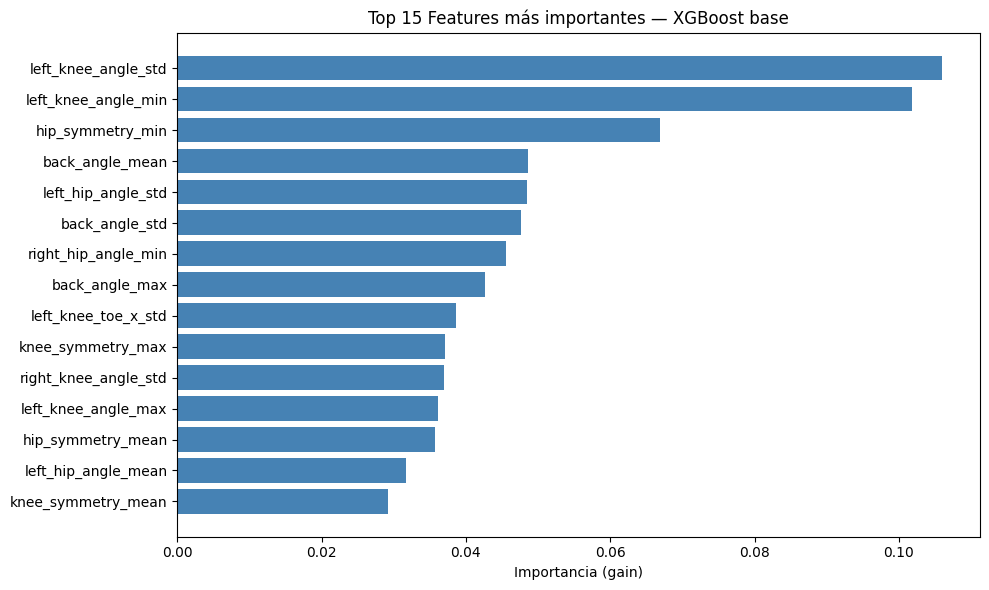

Top 10 features:
  1. left_knee_angle_std: 0.1060
  2. left_knee_angle_min: 0.1018
  3. hip_symmetry_min: 0.0669
  4. back_angle_mean: 0.0485
  5. left_hip_angle_std: 0.0485
  6. back_angle_std: 0.0477
  7. right_hip_angle_min: 0.0456
  8. back_angle_max: 0.0426
  9. left_knee_toe_x_std: 0.0386
  10. knee_symmetry_max: 0.0371


In [ ]:
# Feature Importance (XGBoost base) 

importances = xgb_clf.feature_importances_
idx_sorted = np.argsort(importances)[::-1]

top_n = min(15, len(feature_cols))
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importances[idx_sorted[:top_n]][::-1], color="steelblue")
plt.yticks(range(top_n), [feature_cols[i] for i in idx_sorted[:top_n]][::-1])
plt.xlabel("Importancia (gain)")
plt.title("Top 15 Features más importantes — XGBoost base")
plt.tight_layout()
plt.show()

print("Top 10 features:")
for i in range(min(10, len(feature_cols))):
    name = feature_cols[idx_sorted[i]]
    print(f"  {i+1}. {name}: {importances[idx_sorted[i]]:.4f}")

---
## 9. Comparación: XGBoost vs. Reglas Biomecánicas

### Clasificador por reglas biomecánicas

El `SquatFormClassifier` (definido en `src/squat_classifier.py`) evalúa los mismos ángulos extraídos por YOLOv8-pose mediante **umbrales fijos** derivados de la literatura deportiva:

| Criterio | Umbral | Fundamento |
|---|---|---|
| Profundidad de rodilla | mínimo ≈ 90°, rango 70°–110° | Biomecánica de la sentadilla |
| Ángulo de espalda | inclinación media 15°–50° | Rango seguro para sentadilla con barra alta |
| Alineación rodilla-tobillo | desplazamiento < 40 px | Alineamiento articular seguro |
| Simetría bilateral | diferencia izquierda/derecha < 12° | Indicador de desequilibrio muscular |
| Estabilidad | rango de movimiento > 60° | Criterio de sentadilla completa |

### Protocolo de comparación justa

Para que la evaluación sea válida, **los tres modelos se evalúan sobre el mismo conjunto de prueba** definido por `idx_test`. El clasificador XGBoost no tuvo acceso a estas muestras durante el entrenamiento. Las reglas biomecánicas, al no requerir entrenamiento, se evalúan sobre el mismo subconjunto para garantizar la comparabilidad.

  Comparación sobre TEST SET (datos no vistos durante entrenamiento)
  n_test = 12 muestras  |  0=4 buenas, 1=8 malas
Modelo                     Accuracy       F1      AUC
--------------------------------------------------------------
Reglas biomecánicas          66.67%   0.7500   0.5938
XGBoost base                 66.67%   0.7500   0.7500
XGBoost tuned (grid)         66.67%   0.7500   0.7188
  (Reglas no tienen training → evaluarlas en test set es equivalente al completo)


── Reglas biomecánicas ──────────────────────────────────
              precision    recall  f1-score   support

       Buena       0.50      0.50      0.50         4
        Mala       0.75      0.75      0.75         8

    accuracy                           0.67        12
   macro avg       0.62      0.62      0.62        12
weighted avg       0.67      0.67      0.67        12

── XGBoost tuned ───────────────────────────────────────
              precision    recall  f1-score   support

       Buena       0.5

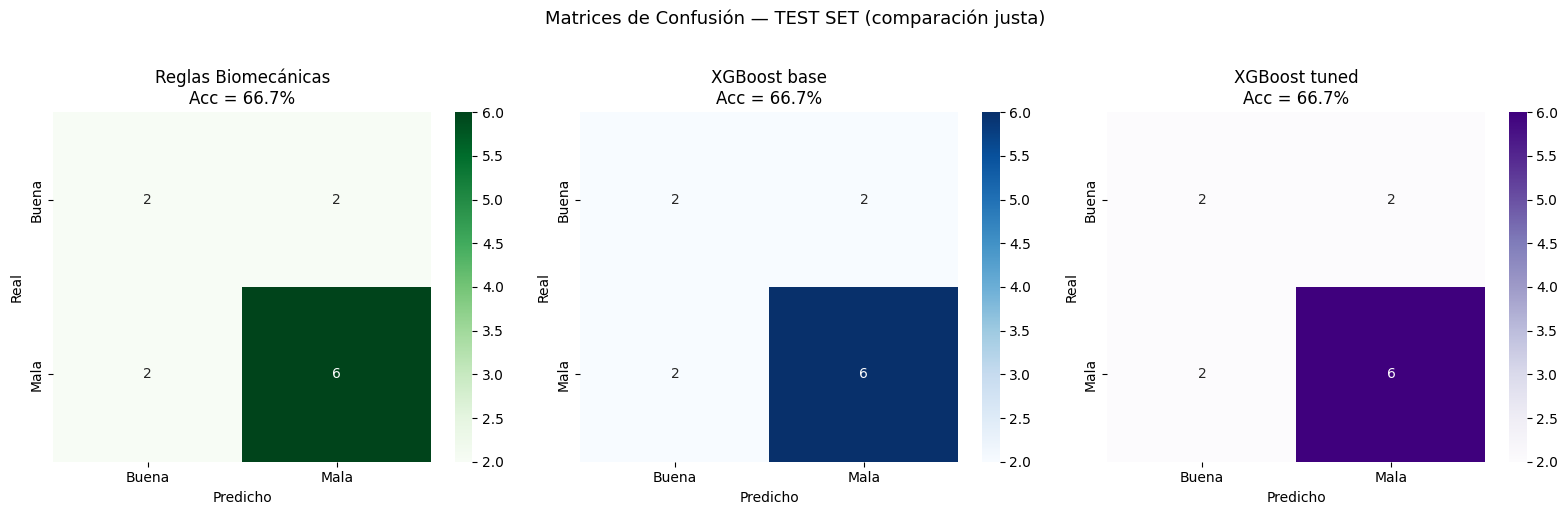

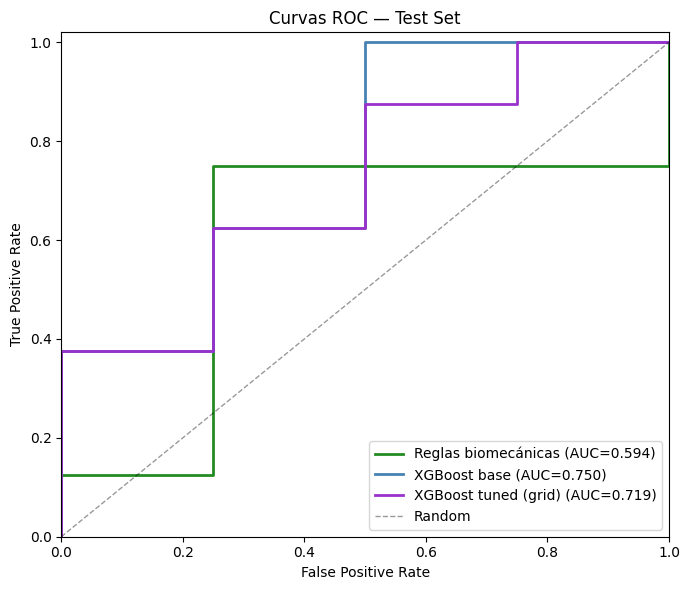


🔍 Casos donde Reglas y XGBoost tuned no coinciden: 6 / 12
       video              class  label  reglas_pred  xgb_pred  reglas_score  xgb_score
IMG_1013.MOV squatmal_ejecutado      1            0         1         0.192      0.938
IMG_1054.MOV squatmal_ejecutado      1            1         0         0.682      0.422
IMG_1054.MOV squatmal_ejecutado      1            1         0         0.421      0.291
IMG_0986.MOV     squat_correcto      0            0         1         0.278      0.900
IMG_1053.MOV squatmal_ejecutado      1            0         1         0.174      0.905
IMG_1050.MOV     squat_correcto      0            1         0         0.408      0.392

  Interpretación: pred=0 → Buena forma, pred=1 → Mala forma

🤝 Coincidencia global Reglas vs XGBoost tuned: 50.0%


In [ ]:
# Comparación justa: todos los modelos sobre el mismo TEST SET 
# Usamos idx_test para obtener las filas de df que corresponden al test set.

import sys
sys.path.insert(0, str(Path.cwd()))
from src.squat_classifier import SquatFormClassifier

df_test = df.iloc[idx_test].reset_index(drop=True)

rule_clf = SquatFormClassifier()
rule_preds  = []
rule_scores = []
for _, row in df_test.iterrows():
    feats = {k: row[k] for k in feature_cols if k in row}
    rule_preds.append(int(rule_clf.predict([feats])[0]))
    rule_scores.append(float(rule_clf.predict_proba([feats])[0][1]))

rule_preds  = np.array(rule_preds)
rule_scores = np.array(rule_scores)

# XGBoost base y tuned sobre X_test
xgb_preds_test  = xgb_clf.predict(X_test)
xgb_scores_test = xgb_clf.predict_proba(X_test)[:, 1]
best_preds_test  = best_clf.predict(X_test)
best_scores_test = best_clf.predict_proba(X_test)[:, 1]

# Tabla comparativa

print("=" * 62)
print("  Comparación sobre TEST SET (datos no vistos durante entrenamiento)")
print("=" * 62)
print(f"  n_test = {len(y_test)} muestras  |  0={sum(y_test==0)} buenas, 1={sum(y_test==1)} malas")
print(f"{'Modelo':<25} {'Accuracy':>9} {'F1':>8} {'AUC':>8}")
print("-" * 62)
for name, preds, scores in [
    ("Reglas biomecánicas",  rule_preds,    rule_scores),
    ("XGBoost base",         xgb_preds_test, xgb_scores_test),
    ("XGBoost tuned (grid)", best_preds_test, best_scores_test),
]:
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, zero_division=0)
    try:
        auc = roc_auc_score(y_test, scores)
    except Exception:
        auc = float("nan")
    print(f"{name:<25} {acc:>9.2%} {f1:>8.4f} {auc:>8.4f}")
print("=" * 62)
print("  (Reglas no tienen training → evaluarlas en test set es equivalente al completo)")

# Classification reports completos

print("\n\n── Reglas biomecánicas ")
print(classification_report(y_test, rule_preds, target_names=["Buena", "Mala"]))

print("── XGBoost tuned")
print(classification_report(y_test, best_preds_test, target_names=["Buena", "Mala"]))

# Confusion matrices lado a lado 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, preds, title, cmap in [
    (axes[0], rule_preds,    "Reglas Biomecánicas", "Greens"),
    (axes[1], xgb_preds_test,"XGBoost base",        "Blues"),
    (axes[2], best_preds_test,"XGBoost tuned",      "Purples"),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["Buena", "Mala"], yticklabels=["Buena", "Mala"], ax=ax)
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")
    acc = accuracy_score(y_test, preds)
    ax.set_title(f"{title}\nAcc = {acc:.1%}")

plt.suptitle("Matrices de Confusión — TEST SET (comparación justa)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Curvas ROC superpuestas

fig, ax = plt.subplots(figsize=(7, 6))

for name, scores, color in [
    ("Reglas biomecánicas",  rule_scores,    "forestgreen"),
    ("XGBoost base",         xgb_scores_test,"steelblue"),
    ("XGBoost tuned (grid)", best_scores_test,"darkorchid"),
]:
    try:
        fpr, tpr, _ = roc_curve(y_test, scores)
        auc = roc_auc_score(y_test, scores)
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.3f})")
    except Exception:
        pass

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC — Test Set")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

# Análisis de desacuerdos

disagree_mask = rule_preds != best_preds_test
n_disagree = disagree_mask.sum()
print(f"\nCasos donde Reglas y XGBoost tuned no coinciden: {n_disagree} / {len(y_test)}")

if n_disagree > 0:
    disagree_df = df_test[disagree_mask][["video", "class", "label"]].copy()
    disagree_df["reglas_pred"]  = rule_preds[disagree_mask]
    disagree_df["xgb_pred"]     = best_preds_test[disagree_mask]
    disagree_df["reglas_score"] = rule_scores[disagree_mask].round(3)
    disagree_df["xgb_score"]    = best_scores_test[disagree_mask].round(3)
    print(disagree_df.to_string(index=False))
    print("\n  Interpretación: pred=0 → Buena forma, pred=1 → Mala forma")

agreement = (rule_preds == best_preds_test).mean()
print(f"\nCoincidencia global Reglas vs XGBoost tuned: {agreement:.1%}")

### Resultados de la comparación

Los tres enfoques obtienen resultados equivalentes sobre el conjunto de prueba de 12 muestras.

| Modelo | Accuracy | F1 | AUC |
|---|---|---|---|
| Reglas biomecánicas | 66.7% | 0.750 | — |
| XGBoost base | 66.7% | 0.750 | 0.750 |
| XGBoost optimizado (GridSearch) | 66.7% | 0.750 | 0.719 |

**Análisis de los resultados:**

1. **El clasificador ML no supera al basado en reglas con el dataset actual.** Con 19 videos y 46 muestras a nivel de track, el modelo XGBoost no dispone de suficiente variabilidad para aprender patrones más discriminativos que los umbrales biomecánicos definidos manualmente.

2. **Los 4 errores corresponden a casos ambiguos para todos los enfoques.** El hecho de que los tres métodos fallen en los mismos videos indica que esas ejecuciones presentan ángulos en zona limítrofe, sin una señal clara desde ninguna perspectiva de análisis.

3. **Las reglas biomecánicas son preferibles en este contexto**, dado que ofrecen interpretabilidad directa, no requieren datos etiquetados y producen el mismo rendimiento que el clasificador ML.

4. **Condiciones para que XGBoost aporte ventaja:** se requiere un dataset de al menos 50 videos con mayor diversidad de ejecutantes, ángulos de cámara y niveles de habilidad. La infraestructura de extracción de características está preparada para reentrenar el modelo sin modificar la aplicación.

---
## 10. Serialización del Modelo

Se persiste el **modelo óptimo obtenido por GridSearchCV** (`best_clf`) junto con los metadatos necesarios para su uso en producción:

- `feature_cols`: orden exacto de las características que espera el modelo como entrada.
- `best_params`: hiperparámetros óptimos identificados durante la búsqueda exhaustiva.
- `scale_pos_weight`: valor utilizado para la corrección del desbalance de clases.
- `cv_auc_mean`: AUC promedio en validación cruzada, como referencia del rendimiento esperado en producción.

El archivo `.pkl` es compatible con la interfaz de `app.py` y puede reemplazar al `SquatFormClassifier` en el pipeline de inferencia si se dispone de un dataset de mayor tamaño que justifique el uso del clasificador ML.

In [ ]:
# Guardar el mejor modelo (tuned)

os.makedirs(OUTPUT_MODEL.parent, exist_ok=True)
joblib.dump(best_clf, str(OUTPUT_MODEL))
size_kb = Path(OUTPUT_MODEL).stat().st_size / 1024
print(f"Modelo guardado: {OUTPUT_MODEL} ({size_kb:.1f} KB)")

# Guardar feature_cols + metadatos del entrenamiento
meta = {
    "feature_cols": feature_cols,
    "label_map": {"Buena": 0, "Mala": 1},
    "best_params": grid_search.best_params_,
    "scale_pos_weight": scale_pos_weight,
    "cv_auc_mean": float(cv_auc.mean()),
}
meta_path = OUTPUT_MODEL.with_suffix(".json")
import json
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"Metadata guardada: {meta_path}")

# Verificar carg
loaded = joblib.load(str(OUTPUT_MODEL))
test_pred_loaded = loaded.predict(X_test)
reload_acc = accuracy_score(y_test, test_pred_loaded)
print(f"\n🔁 Verificación de carga: accuracy = {reload_acc:.2%}")
assert reload_acc == acc_best, "Accuracy mismatch después de recargar"
print("Modelo cargado correctamente — todo OK")

✅ Modelo guardado: models\xgboost_squat.pkl (82.7 KB)
✅ Metadata guardada: models\xgboost_squat.json

🔁 Verificación de carga: accuracy = 66.67%
✅ Modelo cargado correctamente — todo OK


---
## Conclusiones

El presente notebook implementó un pipeline completo de clasificación de la técnica de sentadilla mediante visión por computador y aprendizaje automático supervisado. A continuación se presentan las conclusiones principales:

**1. Viabilidad del pipeline de extracción de características.**
YOLOv8-pose demostró ser una herramienta eficaz para la detección y seguimiento de keypoints corporales en videos de entrenamiento. El algoritmo de seguimiento greedy permitió generar 46 muestras a nivel de persona (tracks) a partir de 19 videos, con un procesamiento reproducible y sin dependencia de dispositivos especializados.

**2. Rendimiento equivalente de los enfoques evaluados.**
Los tres modelos comparados — reglas biomecánicas, XGBoost base y XGBoost optimizado — obtuvieron una exactitud idéntica del 66.7% sobre el conjunto de prueba (12 muestras). Esta convergencia indica que el tamaño actual del dataset es insuficiente para que el clasificador ML aproveche su mayor capacidad expresiva frente a los umbrales biomecánicos fijos.

**3. Preferencia por el enfoque basado en reglas para datasets pequeños.**
El clasificador por reglas biomecánicas resulta preferible en el contexto actual: no requiere datos de entrenamiento, es directamente interpretable y produce resultados equivalentes al modelo ML. Este hallazgo es consistente con la literatura sobre aprendizaje automático en dominios con datos escasos.

**4. Buenas prácticas de Machine Learning aplicadas.**
Se implementaron técnicas estándar para mitigar los efectos del dataset reducido y del desbalance de clases: `scale_pos_weight = 0.59`, validación cruzada estratificada de 5 pliegues (Accuracy: 69.6% ± 14.7%, F1: 0.768 ± 0.125, AUC: 0.689 ± 0.194) y GridSearchCV optimizando ROC-AUC. Los hiperparámetros óptimos encontrados fueron: `learning_rate=0.05`, `max_depth=3`, `n_estimators=100`, `subsample=0.8`.

**5. Proyección y trabajo futuro.**
Para que el clasificador ML supere al basado en reglas, se estima necesario un conjunto de al menos 50 videos con mayor diversidad de ejecutantes, ángulos de cámara y niveles de habilidad. La infraestructura de extracción de características está preparada para reentrenar el modelo sin modificar la aplicación. Una línea de trabajo futura de interés es reemplazar la agregación estadística por modelos secuenciales (LSTM o Transformer temporal) que aprovechen la información dinámica de los ángulos fotograma a fotograma.